In [70]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,classification_report
from sklearn.ensemble import AdaBoostRegressor

In [71]:
df = pd.read_csv("speech_recognition_transcription.csv")
df.drop(columns=["audio_id","file_name","sample_rate_hz"], inplace=True)
df.head()

,duration_sec,mfcc_mean,mel_spectrogram_mean,log_mel_spectrogram_mean,pitch_hz,energy,rms_energy,zero_crossing_rate,delta_features_mean,delta_delta_features_mean,transcript_text
0,22.71,-101.559,151.356,-7.479,166.49,0.3602,0.2399,0.1244,-2.925,-1.551,Participants discussed evaluation metrics befo...
1,9.01,-78.185,92.299,-6.230,205.48,0.4867,0.4312,0.0818,3.292,-0.948,The discussion scheduled the final roadmap to ...
2,28.19,-90.366,215.363,-1.969,75.00,0.3829,0.2852,0.0316,1.473,-2.634,The discussion presented the final roadmap bef...
3,16.63,-77.621,173.317,-7.079,145.05,0.5582,0.4695,0.1090,0.972,0.198,"In this client call, the speaker explained noi..."
4,24.19,-40.735,218.823,-4.622,169.27,0.5205,0.3769,0.0827,1.119,-0.605,The discussion confirmed customer feedback for...


In [72]:
pitch_min = df['pitch_hz'].min()
pitch_max = df['pitch_hz'].max()
df['pitch_norm'] = (df['pitch_hz'] - pitch_min) / (pitch_max - pitch_min)

# Low Energy = Patient is weak/critical
energy_min = df['energy'].min()
energy_max = df['energy'].max()
df['energy_norm'] = 1.0 - ((df['energy'] - energy_min) / (energy_max - energy_min))


# 2. TEXT NLP KEYWORD MATCHING ENGINE
# Medical emergency ke crucial words ki dictionary list
emergency_keywords = [
    'pain', 'chest', 'breathing', 'breath', 'emergency', 'blood', 
    'accident', 'severe', 'heart', 'choking', 'stroke', 'injury'
]

def calculate_text_score(text):
    text_clean = str(text).lower()
    # Check karenge ki kitne emergency keywords match ho rahe hain
    match_count = sum(1 for word in emergency_keywords if word in text_clean)
    
    # Agar 1 ya 1 se zyada words hain toh full weight (1), nahi toh 0
    return 1.0 if match_count > 0 else 0.0

# Keyword matching function ko pooray text column par chalao
df['text_score'] = df['transcript_text'].apply(calculate_text_score)


# 3. FINAL TARGET BLENDING (Weighted Formula)
# Text ko 50% weight, Voice Pitch ko 25%, aur Voice Weakness/Energy ko 25% weight diya
df['urgency_score'] = (df['text_score'] * 0.50) + (df['pitch_norm'] * 0.25) + (df['energy_norm'] * 0.25)


# 4. TEMPORARY COLUMNS KI SAFAI
# Jin intermediate columns se math calculate kiya, unhe drop kar dete hain
df = df.drop(columns=['pitch_norm', 'energy_norm', 'text_score'])

print("🎯 Target Column 'urgency_score' successfully created!")
print(df[['transcript_text', 'pitch_hz', 'energy', 'urgency_score']].head())

🎯 Target Column 'urgency_score' successfully created!
                                     transcript_text  pitch_hz  energy  \
0  Participants discussed evaluation metrics befo...    166.49  0.3602   
1  The discussion scheduled the final roadmap to ...    205.48  0.4867   
2  The discussion presented the final roadmap bef...     75.00  0.3829   
3  In this client call, the speaker explained noi...    145.05  0.5582   
4  The discussion confirmed customer feedback for...    169.27  0.5205   

   urgency_score  
0       0.264398  
1       0.275348  
2       0.155495  
3       0.188700  
4       0.225783  


In [73]:
df.head()

,duration_sec,mfcc_mean,mel_spectrogram_mean,log_mel_spectrogram_mean,pitch_hz,energy,rms_energy,zero_crossing_rate,delta_features_mean,delta_delta_features_mean,transcript_text,urgency_score
0,22.71,-101.559,151.356,-7.479,166.49,0.3602,0.2399,0.1244,-2.925,-1.551,Participants discussed evaluation metrics befo...,0.264398
1,9.01,-78.185,92.299,-6.230,205.48,0.4867,0.4312,0.0818,3.292,-0.948,The discussion scheduled the final roadmap to ...,0.275348
2,28.19,-90.366,215.363,-1.969,75.00,0.3829,0.2852,0.0316,1.473,-2.634,The discussion presented the final roadmap bef...,0.155495
3,16.63,-77.621,173.317,-7.079,145.05,0.5582,0.4695,0.1090,0.972,0.198,"In this client call, the speaker explained noi...",0.188700
4,24.19,-40.735,218.823,-4.622,169.27,0.5205,0.3769,0.0827,1.119,-0.605,The discussion confirmed customer feedback for...,0.225783


In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

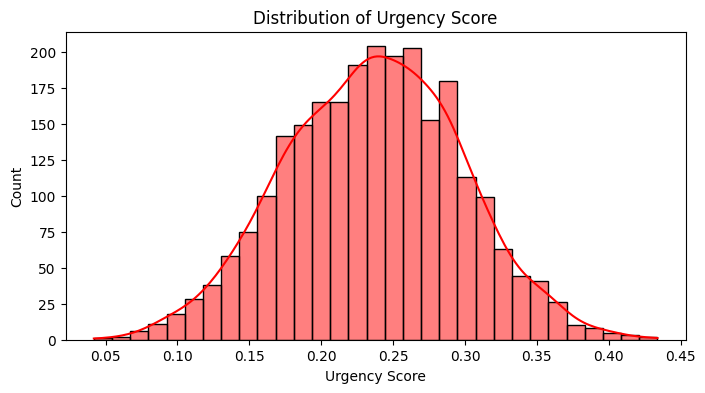

In [75]:
plt.figure(figsize=(8, 4))
sns.histplot(df['urgency_score'], kde=True, color='red')
plt.title('Distribution of Urgency Score')
plt.xlabel('Urgency Score')
plt.ylabel('Count')
plt.show()

In [76]:
df.drop("transcript_text",axis=1,inplace=True)
df.head()

,duration_sec,mfcc_mean,mel_spectrogram_mean,log_mel_spectrogram_mean,pitch_hz,energy,rms_energy,zero_crossing_rate,delta_features_mean,delta_delta_features_mean,urgency_score
0,22.71,-101.559,151.356,-7.479,166.49,0.3602,0.2399,0.1244,-2.925,-1.551,0.264398
1,9.01,-78.185,92.299,-6.230,205.48,0.4867,0.4312,0.0818,3.292,-0.948,0.275348
2,28.19,-90.366,215.363,-1.969,75.00,0.3829,0.2852,0.0316,1.473,-2.634,0.155495
3,16.63,-77.621,173.317,-7.079,145.05,0.5582,0.4695,0.1090,0.972,0.198,0.188700
4,24.19,-40.735,218.823,-4.622,169.27,0.5205,0.3769,0.0827,1.119,-0.605,0.225783


In [77]:
num_cols = df.select_dtypes("number").columns.tolist()
num_cols.pop(-1)

print(num_cols)

['duration_sec', 'mfcc_mean', 'mel_spectrogram_mean', 'log_mel_spectrogram_mean', 'pitch_hz', 'energy', 'rms_energy', 'zero_crossing_rate', 'delta_features_mean', 'delta_delta_features_mean']


In [78]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [79]:
num_pipeline = Pipeline([
    ("impute",SimpleImputer(strategy="median")),
    ("skew",PowerTransformer(method="yeo-johnson")),
    ("scale",StandardScaler())
])

num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('skew', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a

In [80]:
preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_na

In [81]:
X = df.drop("urgency_score",axis=1)
y = df["urgency_score"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

X.head()

,duration_sec,mfcc_mean,mel_spectrogram_mean,log_mel_spectrogram_mean,pitch_hz,energy,rms_energy,zero_crossing_rate,delta_features_mean,delta_delta_features_mean
0,22.71,-101.559,151.356,-7.479,166.49,0.3602,0.2399,0.1244,-2.925,-1.551
1,9.01,-78.185,92.299,-6.230,205.48,0.4867,0.4312,0.0818,3.292,-0.948
2,28.19,-90.366,215.363,-1.969,75.00,0.3829,0.2852,0.0316,1.473,-2.634
3,16.63,-77.621,173.317,-7.079,145.05,0.5582,0.4695,0.1090,0.972,0.198
4,24.19,-40.735,218.823,-4.622,169.27,0.5205,0.3769,0.0827,1.119,-0.605


In [82]:
model_pipeline = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("AdaBoostRegressor",AdaBoostRegressor(random_state=42))
])

model_pipeline.fit(X_train,y_train)
rf_preds = model_pipeline.predict(X_test)
rf_preds_train = model_pipeline.predict(X_train)

rf_r2_testing = r2_score(y_test,rf_preds)
rf_r2_training = r2_score(y_train,rf_preds_train)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")

Accuracy of Training 0.9628629150892255
Accuracy of Testing 0.9588230284104782


In [84]:
from joblib import dump

dump(model_pipeline,"model_pipeline.pkl")

['model_pipeline.pkl']